In [1]:
%pip install "torch==2.13.0" "transformers==5.15.1" scikit-learn tqdm plotly pandas ipywidgets nbformat matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import csv
import json
import time

import torch
from transformers import pipeline
from tqdm.notebook import tqdm
import plotly.express as px
import pandas as pd
from sklearn.decomposition import PCA

In [3]:
# Load list of subject terms for processing

with open('input/subject_terms.txt', 'r') as f:
    subject_terms = [line.strip() for line in f.readlines() if line.strip()]

subject_terms[:5]

['3 rs', '311 calls', '9-1-1', '911', 'AIDS']

In [4]:
# Load the categories and their descriptions
#
# Categories are stored as json objects:
# [{ "name": "...", "description": "..." }, ...]

with open('input/categories.json', 'r') as f:
    categories_json = json.load(f)

categories_short = [cat['name'] for cat in categories_json]
# Target verbose format: "<name>: <description>"
categories_verbose = [cat['name'] + ': ' + cat['description'] for cat in categories_json]

categories_verbose[:5]

['Accessibility: This is about accessibility for people with disabilities (the disabled), such as wheel-trans, wheelchairs, mobility aids, accessible parking permits, AODA, barrier-free design, accessible taxis, accessible parking, and mobility devices. Inputs that contain accessible or disabled as descriptors belong here, NOT in Governance & City Hall.',
 'Animals & Wildlife: Concerns about wild animals in urban or suburban areas, including animal sightings, injured or sick wild animals, and wildlife removal or deterrence. Covers all wild animals including raccoons, coyotes, skunks, snakes, squirrels, bats, deer, foxes, chickens, and wild birds (geese, gulls, pigeons). Also covers integrated pest management programs for rodents and invasive species. Excludes domestic pets (cats and dogs). Excludes natural habitat preservation.',
 'Arts, Culture & Events: This is about arts, culture, events, and tourism, such as Canadian National Exhibition (CNE), festivals, museums, public art, theatr

In [5]:
# Detect processing device and estimate batch size
# Values for model_batch_size are dynamic based on available memory
import os

if torch.cuda.is_available():
    device = "cuda" # GPU
    # Estimate batch size based on GPU VRAM
    free_bytes, _ = torch.cuda.mem_get_info()
    free_gb = free_bytes / (1024 ** 3)
    model_batch_size = min(max(int(free_gb * 1024 / 50), 8), 128) # min: 8, max: 128
elif torch.backends.mps.is_available():
    device = "mps" # Apple silicon
    # Estimate batch size based on system memory
    total_gb = os.sysconf('SC_PAGE_SIZE') * os.sysconf('SC_PHYS_PAGES') / (1024 ** 3)
    if total_gb >= 32:
        model_batch_size = 32
    elif total_gb >= 16:
        model_batch_size = 16
    else:
        model_batch_size = 8
else:
    device = "cpu"
    model_batch_size = 8

print(f"Using device {device} with batch_size {model_batch_size}")

Using device mps with batch_size 16


In [6]:
# Load model
clf = pipeline(
    "zero-shot-classification",
    model="MoritzLaurer/deberta-v3-large-zeroshot-v2.0",
    device=device,
    batch_size=model_batch_size
)

Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

In [7]:
# Answering a question by garo - this is a test of the model
# result = clf("assault", ['crime', 'safety', 'climate'], multi_label=True)
# result

In [8]:
#this is another test of the model
# seq = "hello world!"
# candidate_labels = ["greeting", "food"]
# result = clf(seq, candidate_labels, multi_label=True)
# result

In [9]:
#test case
# TODO: seq not used. The inference is done slightly differently here (eg. hypothesis).
# seq = "3-1-1"
# candidate_labels = categories_verbose
# result = clf(subject_terms[:100], candidate_labels, multi_label=True)
# result

In [10]:
#Commented out to make the notebook easier to read
# dict(zip(result[0]['labels'], result[0]['scores']))

In [11]:
# Compute similarities
# This is where the model uses the descriptions to assign each tag to a category.
# The hypothesis template and the context have been added to halp map the tags to categories.
# This is the most time consuming part, taking over 2 hours on TH laptop.
filename = 'output/similarities.csv'
hypothesis_template = "In Toronto municipal government, this topic relates to {}."

with open(filename, 'w', newline='', encoding='utf-8') as file:
    writer = csv.DictWriter(file, fieldnames=['subject_term'] + categories_short)
    writer.writeheader()

    batch_index = 0
    batch_size = 200
    progress = tqdm(total=len(subject_terms))
    while batch_index * batch_size < len(subject_terms):
        start = time.perf_counter()
        curr_term_batch = subject_terms[batch_index * batch_size:(batch_index + 1) * batch_size]
        contextualized_batch = [f"Toronto City Council agenda topic: {t}" for t in curr_term_batch]

        progress.write(f"Starting batch {batch_index+1}/{(len(subject_terms) + batch_size - 1) // batch_size}")

        results = clf(contextualized_batch, categories_verbose, multi_label=True, hypothesis_template=hypothesis_template)
        output = []
        for result, original_term in zip(results, curr_term_batch):
            score_map = dict(zip(result['labels'], result['scores']))
            row = {short: score_map[verbose] 
                   for short, verbose in zip(categories_short, categories_verbose)}
            row['subject_term'] = original_term  # ← keep the ORIGINAL term, not the contextualized one
            output.append(row)

        writer.writerows(output)
        elapsed = time.perf_counter() - start
        progress.write(f"Completed batch {batch_index+1} in {elapsed:.2f} seconds")
        progress.update(len(curr_term_batch))
        batch_index += 1

    progress.close()

  0%|          | 0/500 [00:00<?, ?it/s]

Starting batch 1/3
Completed batch 1 in 263.87 seconds
Starting batch 2/3
Completed batch 2 in 261.27 seconds
Starting batch 3/3
Completed batch 3 in 129.28 seconds


In [12]:
def reduce_dimensionality(df: pd.DataFrame, num_dimensions: int) -> pd.DataFrame:
    pca = PCA(n_components=num_dimensions)
    pca.fit(df)
    reduced_df = pd.DataFrame(pca.transform(df))
    return reduced_df

In [13]:
df = pd.read_csv('output/similarities.csv')
df['max_val'] = df.drop(columns=['subject_term']).max(axis=1)
df['max_cat'] = df.drop(columns=['subject_term']).idxmax(axis=1)
df

,subject_term,Accessibility,Animals & Wildlife,"Arts, Culture & Events",Biking,"Budget, Taxes & Finance",Business & Economy,Children & Youth,City Employment,Community & People,...,Service Requests & Nuisance Complaints,Sports & Recreation,Information & Libraries,Toronto Hydro & Utilities,Traffic,Urban Planning & Zoning,Waste Management,Water & Sewers,max_val,max_cat
0,3 rs,0.001402,0.023353,0.026081,0.013862,0.002668,0.010288,0.013769,0.009250,0.009055,...,0.009179,0.038865,0.010694,0.013197,0.012031,0.014091,0.011710,0.018671,0.038865,Sports & Recreation
1,311 calls,0.002174,0.013428,0.002364,0.002059,0.000968,0.005448,0.001828,0.002200,0.004315,...,0.008413,0.002087,0.004905,0.001351,0.006488,0.002458,0.003337,0.006985,0.016403,Governance & City Hall
2,9-1-1,0.000934,0.011029,0.001053,0.001758,0.000444,0.001782,0.003722,0.003463,0.001678,...,0.000938,0.001614,0.003204,0.000757,0.008284,0.001449,0.001775,0.004637,0.024940,Public Health
3,911,0.001282,0.006476,0.001782,0.004182,0.001101,0.003248,0.003765,0.002287,0.002059,...,0.000818,0.002141,0.004460,0.004512,0.003318,0.008062,0.005686,0.006133,0.019457,Public Safety
4,AIDS,0.000687,0.001186,0.003729,0.000379,0.000576,0.000306,0.001455,0.001078,0.001469,...,0.000470,0.000331,0.001438,0.000395,0.000318,0.001238,0.000632,0.001552,0.029036,Public Health
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,women,0.000600,0.001317,0.003504,0.001461,0.000691,0.000900,0.001424,0.002581,0.001299,...,0.000684,0.000957,0.001495,0.000550,0.000653,0.001292,0.000864,0.002801,0.008611,Governance & City Hall
496,work from home,0.000667,0.001356,0.000909,0.001362,0.000512,0.003490,0.001188,0.006290,0.001165,...,0.000779,0.000359,0.001370,0.001170,0.000556,0.000866,0.001235,0.004054,0.015649,Governance & City Hall
497,work-based learning,0.000504,0.003324,0.002806,0.003456,0.000576,0.011310,0.003787,0.012747,0.004460,...,0.000773,0.000790,0.004062,0.002378,0.001207,0.003839,0.002444,0.004637,0.014010,Construction & Infrastructure
498,workplaces,0.001114,0.001923,0.000880,0.002256,0.000931,0.021065,0.000357,0.010860,0.000592,...,0.001721,0.000741,0.002463,0.002856,0.000999,0.002516,0.003305,0.004802,0.021065,Business & Economy


In [14]:
reduced_df = pd.DataFrame(df)
reduced_df.drop(columns=['subject_term', 'max_val', 'max_cat'], inplace=True)
reduced_df = reduce_dimensionality(reduced_df, 3)
reduced_df.insert(0, 'subject_term', pd.Series(df['subject_term']))
reduced_df

,subject_term,0,1,2
0,3 rs,-0.003873,0.019381,0.027397
1,311 calls,-0.016403,0.000140,-0.009665
2,9-1-1,-0.016922,0.012280,-0.010500
3,911,-0.014234,0.002266,-0.009650
4,AIDS,-0.018533,0.016117,-0.011778
...,...,...,...,...
495,women,-0.016689,-0.010367,-0.010432
496,work from home,-0.016821,-0.011247,-0.011156
497,work-based learning,-0.014753,-0.011444,-0.010753
498,workplaces,-0.016031,-0.011345,-0.011092


In [15]:
#fig = px.scatter_3d(reduced_df, x=0, y=1, z=2, hover_name='subject_term')
#fig.show()

In [16]:
#fig = px.scatter_matrix(df, dimensions=categories_short[:5], width=1600, height=800, hover_name='subject_term')
#fig.show()

In [17]:
print(df.shape)  # how many rows are going into fit_transform?

(500, 31)


In [18]:
# Clear model from memory, so it can be reclaimed
# Useful for memory-constrained devices, not strictly necessary
del clf
import gc
gc.collect()

import torch
if device == "cuda":
    torch.cuda.empty_cache()
elif device == "mps":
    torch.mps.empty_cache()

In [19]:
# ── Post-processing: rule-based corrections ──────────────────────────────────

# Load rules from file
with open('input/post-processing-rules.json', 'r') as f:
    rules = json.load(f)

for i, rule in enumerate(rules, 1):
    pattern = rule['pattern']
    category = rule['category']

    mask = (
        df['subject_term'].str.contains(pattern, case=False, regex=True) &
        (df['max_val'] < 1.0) &
        (df['max_cat'] != category)
    )
    df.loc[mask, 'max_cat'] = category
    df.loc[mask, 'max_val'] = 1.0
    print(f"Rule {i} | Category: {category}, Pattern: {pattern} | {mask.sum()} terms corrected")

Rule 1 | Category: Pets, Pattern: \bcat\b|\bdog\b|\bpet\b | 0 terms corrected
Rule 2 | Category: Accessibility, Pattern: accessibility|barrier-free|disabled|disabilities|wheelchair|aoda|accessible|mobility | 7 terms corrected
Rule 3 | Category: Budget, Taxes & Finance, Pattern: fees|taxes|grant|finance|financial|tax|levies|invoice|budget|charges|accounts payable|arrears | 12 terms corrected
Rule 4 | Category: Water & Sewers, Pattern: water|sewer|flood|basement flooding|culverts | 1 terms corrected
Rule 5 | Category: Equity, Pattern: equity|bisexual|aboriginal|bilingual|First Nations|two spirited|gender | 0 terms corrected
Rule 6 | Category: Public Safety, Pattern: public safety|911|9-1-1|traffic casualties|traffic fatalities|collision|crashes|crisis response | 2 terms corrected
Rule 7 | Category: City Employment, Pattern: employee | 0 terms corrected
Rule 8 | Category: Climate, Pattern: environment|drive clean | 1 terms corrected
Rule 9 | Category: Service Requests & Nuisance Complaint

In [20]:
# Display top candidate subject terms for each category
threshold = 0.005
top_terms = df[df['max_val'] >= threshold]
#top_terms

In [21]:
top_terms.to_csv("output/top_terms.csv")

In [22]:
df.to_csv("output/all_terms.csv")

In [23]:
# Generate histograms of similarities per category
import plotly.graph_objects as go
import numpy as np

# fig = px.histogram(
#     df, 
#     x='housing',
#     width=500,
#     height=500,
#     nbins=20
# )
fig = go.Figure()
for cat in categories_short:
    fig.add_trace(go.Histogram(
        x=df[cat],
        xbins=dict(
            start=0.0,
            end=1.0,
            size=0.05
        ),
        name=cat.capitalize()
    ))
fig.update_layout(barmode='overlay', width=500)
fig.update_traces(opacity=0.75)
fig.show()

In [24]:
fig = px.histogram(
    df,
    x='max_val',
    color='max_cat',
    marginal='rug',
    hover_name='max_cat',
    width=1000,
    height=750,
    nbins=10,
    title='Most similar category of agenda items\' subject terms',
)
fig.show()

In [25]:
#for cat in categories_short:
#    fig = px.histogram(
#        df,
#        x=cat,
#        marginal='rug',
#        nbins=20,
#        width=500,
#        height=500,
#        # color='max_cat'
#    )
#    fig.show()

In [26]:
# FIX: Use 'max_val' instead of a specific category name
# This shows you the distribution of your model's "Best Guesses"
counts, bins = np.histogram(df['max_val'], bins=[i / 100 for i in range(0, 101, 5)])
bins = .5 * (bins[:-1] + bins[1:])
fig = px.bar(x=bins, y=counts, title="Distribution of Top Confidence Scores")
fig.show()

In [27]:
bins, counts

(array([0.025, 0.075, 0.125, 0.175, 0.225, 0.275, 0.325, 0.375, 0.425,
        0.475, 0.525, 0.575, 0.625, 0.675, 0.725, 0.775, 0.825, 0.875,
        0.925, 0.975]),
 array([358,  42,  17,   7,   1,   1,   2,   2,   1,   1,   2,   0,   0,
          2,   0,   1,   2,   4,   0,  57]))

In [28]:
histogram_table = []
for cat in categories_short:
    counts, bins = np.histogram(df[cat], bins=[i / 100 for i in range(0, 101, 5)])
    histogram_table.append(counts.tolist())
    # bins = .5 * (bins[:-1] + bins[1:])
    # fig = px.bar(x=bins, y=counts)
    # fig.show()
histogram_table = pd.DataFrame(
    histogram_table,
    columns=[
        "0.00 - 0.05",
        "0.05 - 0.10",
        "0.10 - 0.15",
        "0.15 - 0.20",
        "0.20 - 0.25",
        "0.25 - 0.30",
        "0.30 - 0.35",
        "0.35 - 0.40",
        "0.40 - 0.45",
        "0.45 - 0.50",
        "0.50 - 0.55",
        "0.55 - 0.60",
        "0.60 - 0.65",
        "0.65 - 0.70",
        "0.70 - 0.75",
        "0.75 - 0.80",
        "0.80 - 0.85",
        "0.85 - 0.90",
        "0.90 - 0.95",
        "0.95 - 1.00"
    ],
    index=categories_short
)
#histogram_table

In [29]:
histogram_table.to_csv('output/histogram_table.csv')

In [30]:
sorted(categories_short)

['Accessibility',
 'Animals & Wildlife',
 'Arts, Culture & Events',
 'Biking',
 'Budget, Taxes & Finance',
 'Business & Economy',
 'Children & Youth',
 'City Employment',
 'Climate',
 'Community & People',
 'Construction & Infrastructure',
 'Equity',
 'Governance & City Hall',
 'Housing & Homelessness',
 'Information & Libraries',
 'Parks & Green Spaces',
 'Pets',
 'Public Health',
 'Public Safety',
 'Public Transportation',
 'Seniors & Aging',
 'Service Requests & Nuisance Complaints',
 'Sports & Recreation',
 'Toronto Hydro & Utilities',
 'Traffic',
 'Urban Planning & Zoning',
 'Waste Management',
 'Water & Sewers']

---

In [31]:
from collections import Counter

# count_terms = Counter()
# with open('/kaggle/input/datasets/jeromegv/normalized-subject-terms-txt/normalized_subject_terms.txt', 'r', encoding='utf-8') as file:
#     for line in file:
#         line = line.strip()
#         count_terms[line] += 1

# Using the pre-loaded data
count_terms = Counter(subject_terms)

In [32]:
sorted_terms = sorted(count_terms, reverse=True, key=lambda x: count_terms[x])

In [33]:
for term in sorted_terms:
    print(term, count_terms[term])

3 rs 1
311 calls 1
9-1-1 1
911 1
AIDS 1
Avenues 1
Municipal Land Transfer Tax 1
Olympic Games 1
accessibility legislation 1
accessible parking permits 1
accounts payable 1
accreditation 1
adapted programs 1
administrative fees 1
advanced green 1
air quality index 1
anchoring 1
and tolls 1
animal licenses 1
animal registration 1
archaeological digs 1
art galleries (facilities) 1
arts centres 1
attributes in transportation 1
audio 1
automobile body repair shops 1
bankruptcy sales 1
barnes dance 1
basement flooding 1
behaviour 1
behaviour standards 1
benches (street furniture) 1
bicycle routes 1
bike lanes 1
bike sharing 1
bike trails 1
biotech 1
birds 1
blogs 1
blue boxes 1
bmrs 1
board-run community centres 1
boards of governors 1
boat moorings 1
boat rentals 1
boulevard maintenance 1
boulevard vending 1
branding 1
bridge rehabilitation 1
broken concrete 1
budgets 1
budgets and accounts 1
building 1
building designers 1
building retrofits 1
burning leaves 1
bus stations 1
bus stops 1
bu

In [34]:
len(count_terms), df.shape

(500, (500, 31))

In [35]:
df.iloc[4000:4005]['subject_term'], sorted(count_terms)[4000:4005]

(Series([], Name: subject_term, dtype: str), [])

In [36]:
df['count'] = [count_terms[term] for term in sorted(count_terms)]
#df.iloc[4000:4005]

In [37]:
count_terms['smell']

1

In [38]:
df.to_csv('output/all_terms.csv')

In [39]:
# load in a validation file and create a dict

df  = pd.read_csv('input/GT-TAH-June8.csv')
validation_labels = dict(zip(df['subject_term'], df['expected_category']))

validation_terms = list(validation_labels.keys())
validation_expected = list(validation_labels.values())

print(f"Loaded {len(validation_labels)} terms across {len(set(validation_expected))} categories")

Loaded 2700 terms across 28 categories


⚠️  2344 validation term(s) not found in results — they will be excluded.

Overall accuracy: 69.4%  (247/356 correct)

                                        precision    recall  f1-score   support

                         Accessibility       1.00      0.88      0.93         8
                    Animals & Wildlife       0.78      0.88      0.82         8
                Arts, Culture & Events       0.65      0.96      0.78        27
                                Biking       0.44      1.00      0.61         7
               Budget, Taxes & Finance       0.90      0.64      0.75        14
                    Business & Economy       0.92      0.81      0.86        27
                      Children & Youth       0.80      0.80      0.80         5
                       City Employment       0.80      0.67      0.73         6
                               Climate       0.67      0.75      0.71        16
                    Community & People       0.43      0.33      0.38         9


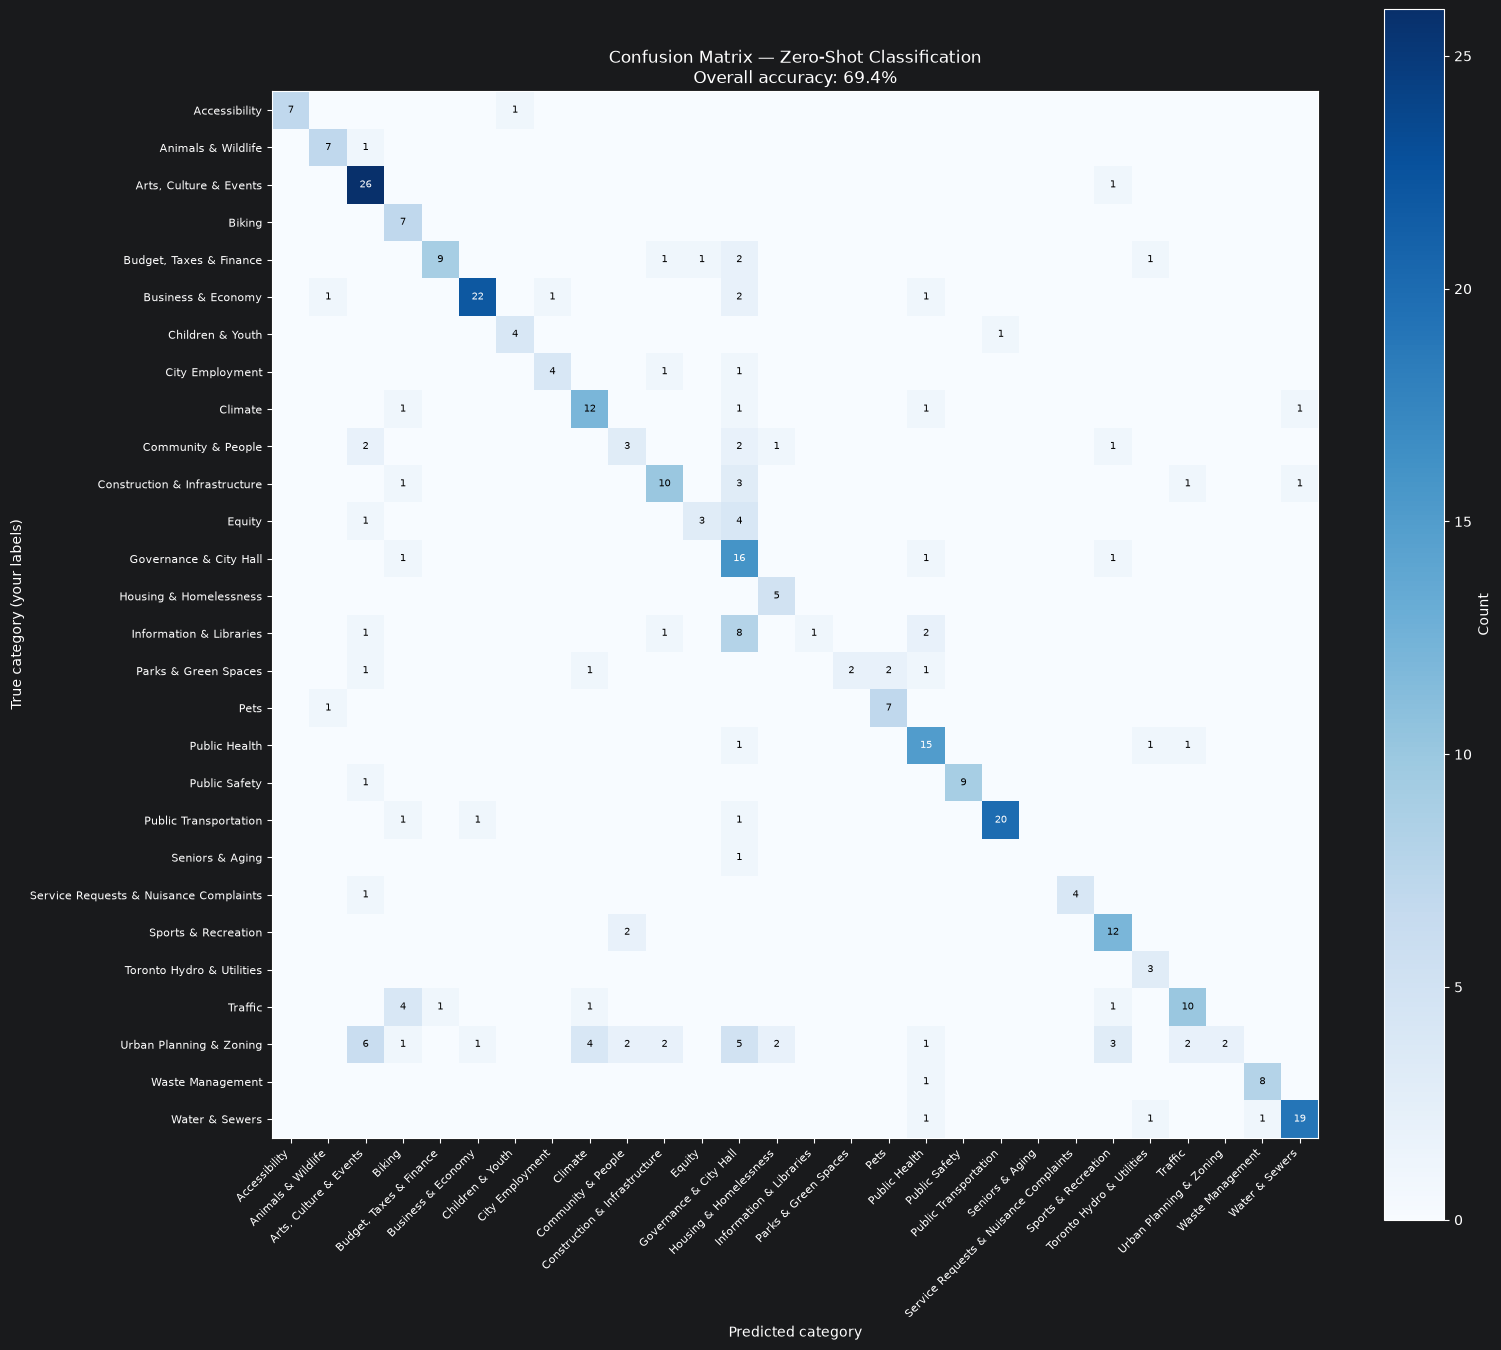

Confusion matrix saved to confusion_matrix.png

Top 15 confusions (true → predicted):
True category                       Predicted category                  Count
-----------------------------------------------------------------------------
Information & Libraries             Governance & City Hall                  8
Urban Planning & Zoning             Arts, Culture & Events                  6
Urban Planning & Zoning             Governance & City Hall                  5
Equity                              Governance & City Hall                  4
Traffic                             Biking                                  4
Urban Planning & Zoning             Climate                                 4
Construction & Infrastructure       Governance & City Hall                  3
Urban Planning & Zoning             Sports & Recreation                     3
Budget, Taxes & Finance             Governance & City Hall                  2
Business & Economy                  Governance & City Ha

In [40]:
# ── Validation: Zero-Shot Classification vs. Manual Labels ──────────────────
# Paste this cell AFTER the cells that define:
#   - validation_labels  (from validation_set.py)
#   - the top_terms.csv results (adjust path below if needed)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.metrics import classification_report, accuracy_score

# ── 1. Load classification results ──────────────────────────────────────────
results_path = "output/top_terms.csv"          # ← update path if needed
df_results = pd.read_csv(results_path)

# ── 2. Remap old category names in max_cat to current dict keys ─────────────
# (needed if the CSV was produced with a previous version of the categories)

df_results["predicted_category"] = df_results["max_cat"]

# ── 3. Build comparison dataframe from validation set ───────────────────────
df_val = pd.DataFrame(
    list(validation_labels.items()),
    columns=["subject_term", "expected_category"]
)

df_merged = df_val.merge(
    df_results[["subject_term", "predicted_category"]],
    on="subject_term",
    how="left"
)

missing = df_merged["predicted_category"].isna().sum()
if missing > 0:
    print(f"⚠️  {missing} validation term(s) not found in results — they will be excluded.")
    df_merged = df_merged.dropna(subset=["predicted_category"])

y_true = df_merged["expected_category"].tolist()
y_pred = df_merged["predicted_category"].tolist()

# ── 4. Overall accuracy ──────────────────────────────────────────────────────
acc = accuracy_score(y_true, y_pred)
print(f"\nOverall accuracy: {acc:.1%}  ({int(acc * len(y_true))}/{len(y_true)} correct)\n")

# ── 5. Per-category report ───────────────────────────────────────────────────
print(classification_report(y_true, y_pred, zero_division=0))

# ── 6. Confusion matrix (heatmap) ───────────────────────────────────────────
all_cats = sorted(set(y_true) | set(y_pred))
n = len(all_cats)
cat_index = {c: i for i, c in enumerate(all_cats)}

matrix = np.zeros((n, n), dtype=int)
for true, pred in zip(y_true, y_pred):
    matrix[cat_index[true]][cat_index[pred]] += 1

fig, ax = plt.subplots(figsize=(16, 14))
im = ax.imshow(matrix, cmap="Blues")

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(all_cats, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(all_cats, fontsize=8)
ax.set_xlabel("Predicted category", fontsize=10)
ax.set_ylabel("True category (your labels)", fontsize=10)
ax.set_title(f"Confusion Matrix — Zero-Shot Classification\nOverall accuracy: {acc:.1%}", fontsize=12)

# Annotate cells that have values
for i in range(n):
    for j in range(n):
        val = matrix[i, j]
        if val > 0:
            colour = "white" if val > matrix.max() * 0.5 else "black"
            ax.text(j, i, str(val), ha="center", va="center",
                    fontsize=7, color=colour)

plt.colorbar(im, ax=ax, label="Count")
plt.tight_layout()
plt.savefig("output/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Confusion matrix saved to confusion_matrix.png")

# ── 7. Most common confusions (off-diagonal) ────────────────────────────────
print("\nTop 15 confusions (true → predicted):")
print(f"{'True category':<35} {'Predicted category':<35} {'Count':>5}")
print("-" * 77)
confusions = []
for i, true_cat in enumerate(all_cats):
    for j, pred_cat in enumerate(all_cats):
        if i != j and matrix[i, j] > 0:
            confusions.append((true_cat, pred_cat, matrix[i, j]))
confusions.sort(key=lambda x: -x[2])
for true_cat, pred_cat, count in confusions[:15]:
    print(f"{true_cat:<35} {pred_cat:<35} {count:>5}")

In [41]:
df_merged.to_csv("validation_out.csv")


In [42]:
score_lookup = df_results.set_index("subject_term")["max_val"]
df_merged["max_val"] = df_merged["subject_term"].map(score_lookup)
df_merged.to_csv("validation_out_withmaxval.csv")